# POW-file: Load, Resample, Plot and Save with Pandas

This requires the pow and CTimeSeries libraries in same folder.

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt 
import pandas as pd
from pow import PowFile
import numpy as np

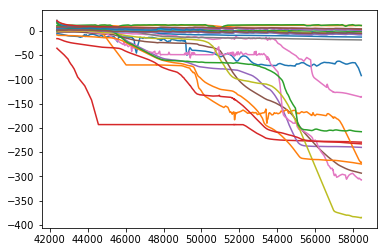

In [1]:
pf = PowFile('test.pow')

df_all = pd.DataFrame()
for ts in pf.timeSeries:
    name = ts.name
    df = pd.DataFrame(ts.DataPoints, columns=["time", name] )
    df = df.set_index("time")
    df_all = pd.concat([df_all, df], axis=1)
_ = plt.plot(df_all)

# Resample using Numpy

In [2]:
stepsize = 30  # stepsize in days

for ts in pf.timeSeries:
    
    # convert to float-array
    times = np.array([i[0] for i in ts.DataPoints], dtype=float)
    values = np.array([i[1] for i in ts.DataPoints], dtype=float)

    # interpolate
    newtimes = np.arange(times.min(),times.max(), stepsize)
    newvalues = np.interp(newtimes, times, values)

    # convert to str-array
    newvalues = np.array(newvalues, dtype=str)
    newtimes = np.array(newtimes, dtype=str)

    # write back to time series
    ts.DataPoints = zip(newtimes, newvalues)
    

... plot again ...

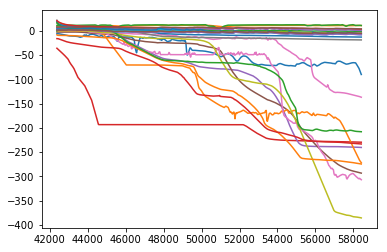

In [3]:
df_all = pd.DataFrame()
for ts in pf.timeSeries:
    name = ts.name
    df = pd.DataFrame(ts.DataPoints, columns=["time", name] )
    df = df.set_index("time")
    df_all = pd.concat([df_all, df], axis=1)
_ = plt.plot(df_all)

# Save to pow and csv

In [4]:
pf.saveTo('resampled.pow')
df_all.to_csv('resampled.dat')